In [2]:
from gerrychain import Graph
from gerrychain import (GeographicPartition, Partition, Graph, MarkovChain, proposals, updaters, constraints, accept, Election)
from gerrychain.proposals import recom, propose_random_flip
from gerrychain.tree import recursive_tree_part, bipartition_tree, find_balanced_edge_cuts_memoization
from gerrychain.metrics import efficiency_gap, mean_median, polsby_popper, partisan_bias
from gerrychain.updaters import cut_edges

import geopandas as gpd
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np

In [ ]:
graph = Graph.from_json("./SC_Processed/output/SC_Processed_Precincts.json")
df = gpd.read_file("./SC_Processed/output/SC_Processed_Precincts.shp")

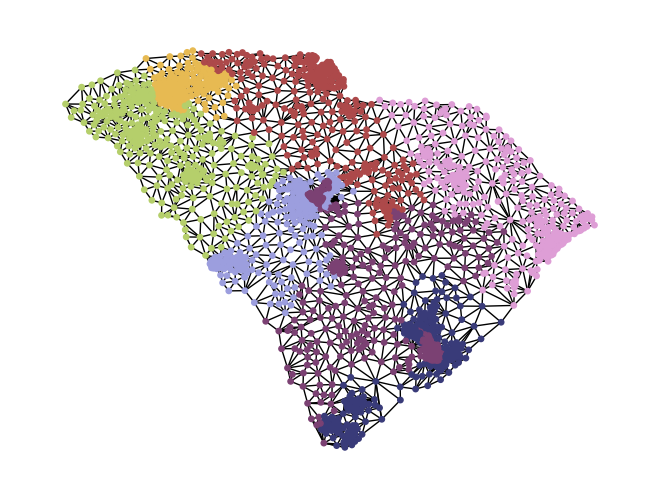

In [4]:
nx.draw(graph, pos={x:(graph.nodes()[x]['C_X'], graph.nodes()[x]['C_Y']) for x in graph.nodes()}, node_color=[graph.nodes()[x]['CON'] for x in graph.nodes()],cmap ='tab20b',node_size=15)

In [ ]:
df.keys()

Index(['PRECINCTID', 'population', 'populati_1', 'G24PRERTRU', 'G24PREDHAR',
       'Total', 'Hispanic', 'NH_White', 'NH_Black', 'NH_Other', 'Total_VAP',
       'Hispanic_V', 'NH_White_V', 'NH_Black_V', 'NH_Other_V', 'COUNTYFP',
       'CON', 'SLDU', 'SLDL', 'C_X', 'C_Y', 'geometry'],
      dtype='object')

In [ ]:
def count_spanning(graph):
    laplacian = nx.laplacian_matrix(graph)
    L = np.delete(np.delete(laplacian.todense(), 0, 0), 1, 1)
    return np.linalg.slogdet(L)[1]

def county_splits(partition, df=df):
    df["current"] = df["PRECINCTID"].map(partition.assignment)

    counties = sum(df.groupby("COUNTYFP")['current'].nunique()>1)
    return counties

election_names = [
    "PRE"
]

num_elections = len(election_names)

election_columns = [
  ['G24PRERTRU','G24PREDHAR']
]

my_updaters = {
    "population": updaters.Tally("population", alias="population"),
    "cut_edges": cut_edges,
    "PP":polsby_popper,
    "county_splits": county_splits
}

elections = [
    Election(
        election_names[i],
        {"Democratic": election_columns[i][1], "Republican": election_columns[i][0]},
    )
    for i in range(num_elections)
]

election_updaters = {election.name: election for election in elections}
for node in graph.nodes():
    graph.nodes()[node]["non_NH_Black"] = graph.nodes()[node]["population"] - graph.nodes()[node]["NH_Black"]

my_updaters.update({"NH_Black":Election("NH_Black",{"NH_Black": "NH_Black", "non_NH_Black": "non_NH_Black"})})
my_updaters.update()

# save percentages

my_updaters.update(election_updaters)


In [5]:
ideal_population = df['population'].sum() / 7 # number of congressional districts
cd_dict = recursive_tree_part(graph, range(7), ideal_population, "population",.02)

In [6]:
tree_partition = GeographicPartition(graph, cd_dict, my_updaters)
CONPart = GeographicPartition(graph, "CON", my_updaters)

In [7]:
print(sum([1/x for x in polsby_popper(tree_partition).values()])/14)

print(mean_median(tree_partition["PRE"]))

print(tree_partition["county_splits"])


2.4211611385044094
0.009858767553427183
24


In [8]:
def pp_constraint(partition):
    return sum([1/x for x in polsby_popper(partition).values()])/7 > 4

def county_constraint(partition):
    return partition['county_splits'] < 11

In [29]:
# proposal function
from functools import partial

proposal = partial(
    recom,
    pop_col="population",
    pop_target=ideal_population,
    epsilon=0.01,
    node_repeats=2,
    region_surcharge = {"COUNTYFP":.55}
)

In [36]:
first_recom_chain = MarkovChain(
    proposal=proposal,
    constraints=[],
    accept=accept.always_accept,
    initial_state=CONPart,
    total_steps=5000
)

In [37]:
cs = [] # county splits
mms = [] # mean median
egs = [] # efficiency gap
pbs = [] # partisan bias
dvp = [] # dem voting perc
pps = [] # polsby popper
bvp = [] # black voting percent
mbvp = [] # max black voting percent
wins = [] # dem wins

i = 0

for part in first_recom_chain: # num of trees to generate

    i += 1
    if i %1000==0:
        print(i)

    cs.append(part['county_splits'])
    mms.append(mean_median(part['PRE']))
    egs.append(efficiency_gap(part['PRE']))
    pbs.append(partisan_bias(part['PRE']))
    dvp.append(sorted(part['PRE'].percents("Democratic")))
    pps.append(sum([1/x for x in polsby_popper(part).values()])/14)
    bvp.append(sorted(part['NH_Black'].percents("NH_Black")))
    mbvp.append(max(bvp[-1]))
    wins.append(part['PRE'].wins("Democratic"))

    ad = dict(part.assignment)

"""
    plt.figure(figsize=(10,4))
    nx.draw(graph, pos={x:(graph.nodes()[x]['C_X'], graph.nodes()[x]['C_Y']) for x in graph.nodes()}, node_color=[ad[x] for x in graph.nodes()],cmap ='tab20b',node_size=15)
    plt.savefig(f'./NC_Markov_gif_1/network_plot_{i}.png')
    plt.close()

    df['current'] = df["PRECINCTID"].map(ad)
    df.plot(column='current',cmap='tab20b')
    plt.axis('off')
    plt.savefig(f'./NC_Markov_gif_1/df_plot{i}.png')
    plt.close()
"""

1000
2000
3000
4000
5000


'\n    plt.figure(figsize=(10,4))\n    nx.draw(graph, pos={x:(graph.nodes()[x][\'C_X\'], graph.nodes()[x][\'C_Y\']) for x in graph.nodes()}, node_color=[ad[x] for x in graph.nodes()],cmap =\'tab20b\',node_size=15)\n    plt.savefig(f\'./NC_Markov_gif_1/network_plot_{i}.png\')\n    plt.close()\n\n    df[\'current\'] = df["PRECINCTID"].map(ad)\n    df.plot(column=\'current\',cmap=\'tab20b\')\n    plt.axis(\'off\')\n    plt.savefig(f\'./NC_Markov_gif_1/df_plot{i}.png\')\n    plt.close()\n'

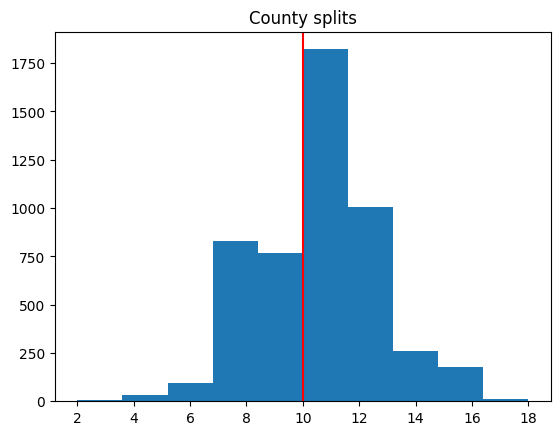

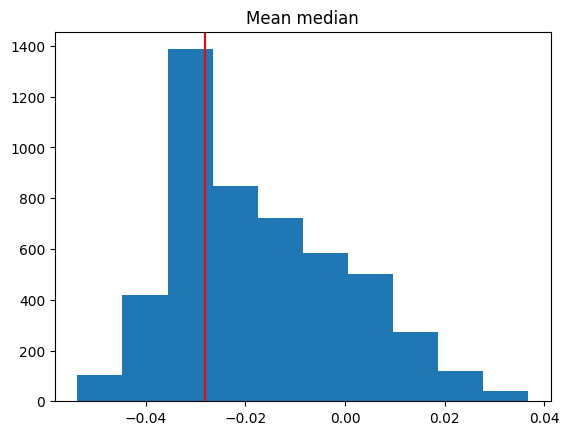

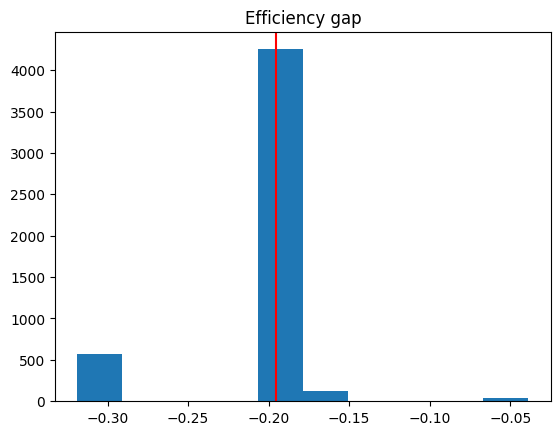

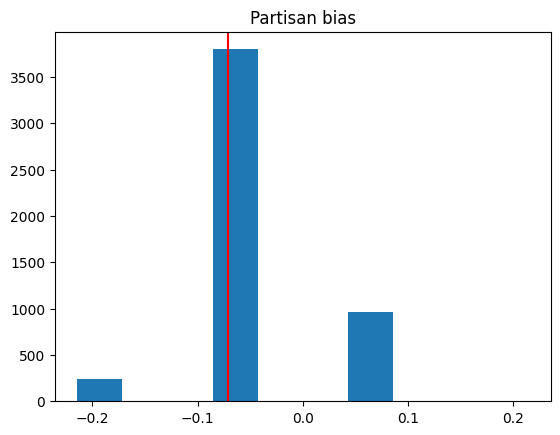

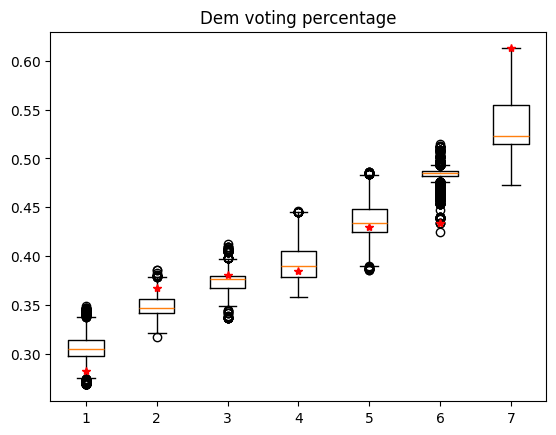

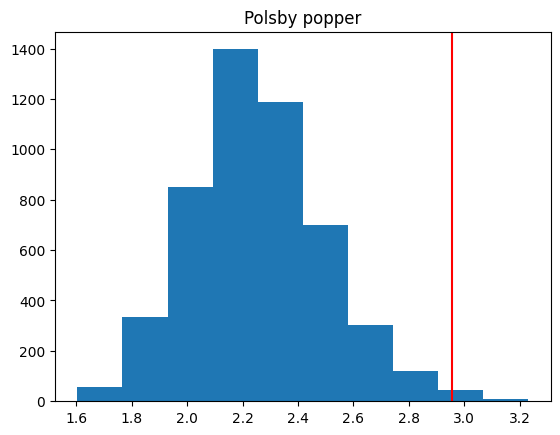

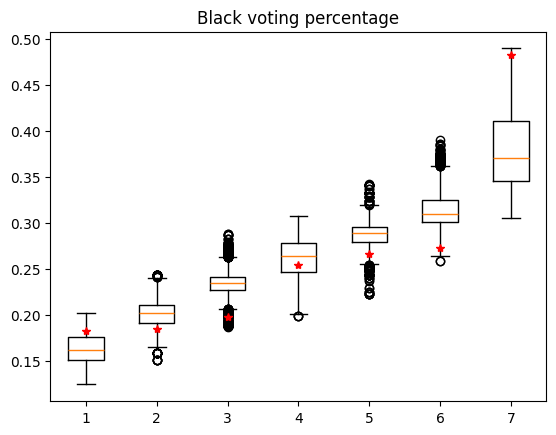

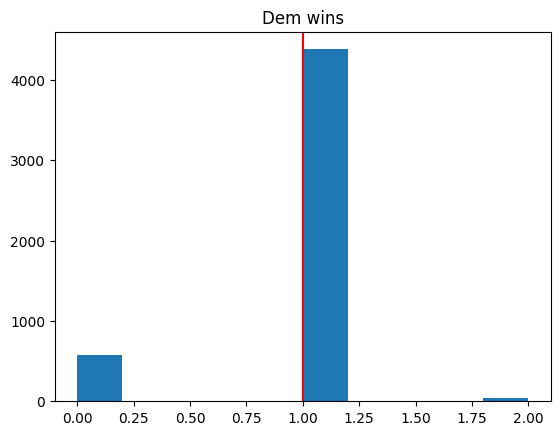

In [38]:
plt.hist(cs)
plt.axvline((CONPart['county_splits']), color='red',label='Enacted')
plt.title("County splits")
plt.show()

plt.hist(mms)
plt.axvline(mean_median(CONPart["PRE"]), color='red',label='Enacted')
plt.title("Mean median")
plt.show()

plt.hist(egs)
plt.axvline(efficiency_gap(CONPart["PRE"]), color='red',label='Enacted')
plt.title("Efficiency gap")
plt.show()

plt.hist(pbs)
plt.axvline(partisan_bias(CONPart["PRE"]), color='red',label='Enacted')
plt.title("Partisan bias")
plt.show()

dvp = np.array(dvp)
plt.boxplot(dvp)
plt.plot(range(1,8),(sorted(CONPart['PRE'].percents("Democratic"))), "*", color='red',label='Enacted')
plt.title("Dem voting percentage")
plt.show()

plt.hist(pps)
plt.axvline(sum([1/x for x in polsby_popper(CONPart).values()])/14, color='red',label='Enacted')
plt.title("Polsby popper")
plt.show()

bvp = np.array(bvp)
plt.boxplot(bvp)
plt.plot(range(1,8),(sorted(CONPart['NH_Black'].percents("NH_Black"))), "*", color='red',label='NH_Black')
plt.title("Black voting percentage")
plt.show()

plt.hist(wins)
plt.axvline(CONPart['PRE'].wins("Democratic"), color='red',label='Enacted')
plt.title("Dem wins")
plt.show()